# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [2]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [8]:
# Try loading one file


df = pd.read_parquet('/content/drive/MyDrive/EDA Assignment/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload
#function to sample the data: given a dataframe, it will split the date time column into date and hour:
def sampleData(df):
  df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
# Step 2: Extract date and hour
  df["date"] = pd.to_datetime(df["tpep_pickup_datetime"].dt.date)
  df["hour"] = df["tpep_pickup_datetime"].dt.hour
# Step 3: Group by date and hour, sample 7% from each group
  sampled_df = df.groupby(["date", "hour"]).apply(
  lambda row: row.sample(frac=0.07, random_state=42) ) # reproducible
  return sampled_df

In [10]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/EDA Assignment/')

# Create a list of all the twelve files to read
file_list = os.listdir()
#print(file_list)

# initialise an empty dataframe
df = pd.DataFrame()
finalsampleddata = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)
        # Reading the current file
        df = pd.read_parquet(file_path)
        sampled_data = sampleData(df)
        finalsampleddata = pd.concat([finalsampleddata, sampled_data])
        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        #sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe

        # Concatenate the sampled data of all the dates to a single dataframe
        #df = finalsampleddata # we initialised this empty DF earlier
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

finalsampleddata.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2654955 entries, (Timestamp('2022-12-31 00:00:00'), np.int32(23), np.int64(80)) to (Timestamp('2023-11-30 00:00:00'), np.int32(23), np.int64(3202559))
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [72]:
# Store the df in csv/parquet
finalsampleddata.to_parquet('/content/drive/MyDrive/EDA_Final_Data/final_data4.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [9]:
# Load the new data file
df = pd.read_parquet("/content/drive/MyDrive/EDA_Final_Data/final_data4.parquet")
df.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2654955 entries, (Timestamp('2022-12-31 00:00:00'), np.int32(23), np.int64(80)) to (Timestamp('2023-11-30 00:00:00'), np.int32(23), np.int64(3202559))
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64

In [10]:
df.head()
df.shape
df.ndim
df.isnull().sum() #90865 nulls in passenger_count, RatecodiID, store_and_fwd_flag,congestion_surchage,Airport_Fee


,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,90865
trip_distance,0
RatecodeID,90865
store_and_fwd_flag,90865
PULocationID,0
DOLocationID,0
payment_type,0


In [11]:
df['RatecodeID'].unique()
print((df['store_and_fwd_flag']=='N').sum()) #for majority of the records store and fwd flag is not set to 'Y'
df['extra'].unique()
print(df['mta_tax'].unique()) #this can be dropped as mta_tax is mostly 0.5 for all records:
print((df['mta_tax']==0.5).sum())
print(df['improvement_surcharge'].unique()) #1,0.3,0,-1
print((df['improvement_surcharge']==1).sum())

2548466
[ 0.5   0.    0.8  -0.5   0.3   0.05  4.    2.5   3.5 ]
2629739
[ 1.   0.3  0.  -1. ]
2651798


#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [12]:
# Fix the index and drop any columns that are not needed

df = df.drop(columns=["mta_tax"])
df = df.drop(columns=["improvement_surcharge"])

df["tolls_amount"] = df["tolls_amount"].apply(lambda x: f"{x:.2f}")
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2654955 entries, 0 to 2654954
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  tip_amount             float64       
 13  tolls_amount           object        
 14  total_amount           float64       
 15  congestion_surcharge   float64       
 16  airport_fee            float64       
 17  date                   datetime64[ns]
 18  hour                  

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [13]:
# Combine the two airport fee columns
# drop airport_fee and store_and_fwd_flag
# Merge by filling missing values
df["Airport_fee"] = df["Airport_fee"].fillna(df["airport_fee"])
df['Airport_fee'].isnull().sum() #12942 null's are there
df = df.drop(columns=["airport_fee"])
df = df.drop(columns=["store_and_fwd_flag"])

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [15]:
# check where values of fare amount are negative
#I am not getting any record with fare amount negative:
tempdata = df[df['fare_amount'] <0]
tempdata['fare_amount'].sum() #no records with fare_amount less than zero:

np.float64(0.0)

Did you notice something different in the `RatecodeID` column for above records?

In [16]:
# Analyse RatecodeID for the negative fare amounts
print((tempdata['total_amount']<0).sum()) #no records with fare_amount < 0
tempdata[['total_amount','RatecodeID']]

# Step 1: Filter rows where total_amount < 0
filtered = tempdata[tempdata["total_amount"] < 0]

# Step 2: Group by RatecodeID and count records
result = filtered.groupby("RatecodeID").size().reset_index(name="total_records")

print("Total records per RatecodeID:\n", result)
#with respect to total_amount majority of them fall into standard rate;

0
Total records per RatecodeID:
 Empty DataFrame
Columns: [RatecodeID, total_records]
Index: []


In [17]:
# Find which columns have negative values

# Only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Columns with negatives
cols_with_negatives = numeric_df.columns[(numeric_df < 0).any()].tolist()
print("Columns with negative values:", cols_with_negatives)

print((numeric_df["extra"] < 0).sum())
print((numeric_df["total_amount"] < 0).sum())
print((numeric_df["Airport_fee"] < 0).sum())
print((numeric_df["congestion_surcharge"] < 0).sum())
print(df["congestion_surcharge"].unique())

Columns with negative values: ['extra', 'total_amount', 'congestion_surcharge', 'Airport_fee']
4
123
24
91
[ 2.5   0.     nan -2.5   2.75  0.5 ]


In [18]:
# fix these negative values
#should we replace negative values with mean? instead of deleting those records?

# Calculate mean of extra non-negative values
extra_mean_value = df.loc[df["extra"] >= 0, "extra"].mean()

# Replace negatives with the mean
df.loc[df["extra"] < 0, "extra"] = extra_mean_value

# Calculate mean of total_amount non-negative values
total_amount_mean_value = df.loc[df["total_amount"] >= 0, "total_amount"].mean()

# Replace negatives with the mean
df.loc[df["total_amount"] < 0, "total_amount"] = total_amount_mean_value

# Calculate mean of Airport_fee non-negative values
Airport_fee_mean_value = df.loc[df["Airport_fee"] >= 0, "Airport_fee"].mean()

# Replace negatives with the mean
df.loc[df["Airport_fee"] < 0, "Airport_fee"] = Airport_fee_mean_value

# Replace negatives with zero for congestion_surcharge
df.loc[df["congestion_surcharge"] < 0, "congestion_surcharge"] = 0


numeric_df = df.select_dtypes(include=["int64", "float64"])
cols_with_negatives = numeric_df.columns[(numeric_df < 0).any()].tolist()
print("Columns with negative values:", cols_with_negatives)


Columns with negative values: []


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [19]:
# Find the proportion of missing values in each column
missing_proportion = df.isna().mean()
print(missing_proportion)

VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          0.034225
trip_distance            0.000000
RatecodeID               0.034225
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
tip_amount               0.000000
tolls_amount             0.000000
total_amount             0.000000
congestion_surcharge     0.034225
date                     0.000000
hour                     0.000000
Airport_fee              0.034225
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [20]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
df.isnull().sum() #12942 nulls in passenger_count, RatecodiID, store_and_fwd_flag,congestion_surchage,Airport_Fee
tempdata = df[df["passenger_count"].isnull()]
tempdata[["passenger_count","RatecodeID","congestion_surcharge","Airport_fee","total_amount"]]

#impute NAN values with Mode:
df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)
#Impute NAN values with mode for RatecodeID, congestion_surcharge, Airport_fee
df["passenger_count"] = df["passenger_count"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2654955 entries, 0 to 2654954
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        int64         
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           int64         
 9   fare_amount            float64       
 10  extra                  float64       
 11  tip_amount             float64       
 12  tolls_amount           object        
 13  total_amount           float64       
 14  congestion_surcharge   float64       
 15  date                   datetime64[ns]
 16  hour                   int32         
 17  Airport_fee            float64       
dtypes: datetime64[ns](1), 

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [22]:
# Fix missing values in 'RatecodeID'
print(df[df["RatecodeID"].isnull()].count())
tempdata = df[df["RatecodeID"].isnull()]
#tempdata[["passenger_count","RatecodeID","store_and_fwd_flag","congestion_surcharge","Airport_fee"]]
df['RatecodeID'].fillna(df['RatecodeID'].mode()[0], inplace=True)
df["RatecodeID"] = df["RatecodeID"].astype(int)
df.info()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
tip_amount               0
tolls_amount             0
total_amount             0
congestion_surcharge     0
date                     0
hour                     0
Airport_fee              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2654955 entries, 0 to 2654954
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        int64         
 4   trip_distance          float64       
 5   RatecodeID             int64         
 6   PULocationID           int64         
 

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [23]:
# handle null values in congestion_surcharge

tempdata = df[df["congestion_surcharge"].isnull()]
df['congestion_surcharge'].fillna(df['congestion_surcharge'].mode()[0], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2654955 entries, 0 to 2654954
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        int64         
 4   trip_distance          float64       
 5   RatecodeID             int64         
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           int64         
 9   fare_amount            float64       
 10  extra                  float64       
 11  tip_amount             float64       
 12  tolls_amount           object        
 13  total_amount           float64       
 14  congestion_surcharge   float64       
 15  date                   datetime64[ns]
 16  hour                   int32         
 17  Airport_fee            float64       
dtypes: datetime64[ns](1), 

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [24]:
# Handle any remaining missing values
print(df[df["Airport_fee"].isnull()].count())
tempdata = df[df["Airport_fee"].isnull()]
#tempdata[["passenger_count","RatecodeID","store_and_fwd_flag","congestion_surcharge","Airport_fee"]]
df['Airport_fee'].fillna(df['Airport_fee'].mode()[0], inplace=True)
df["Airport_fee"] = df["Airport_fee"].astype(int)
df['tolls_amount'] =  df["tolls_amount"].astype(float)
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

print(df[df["Airport_fee"].isnull()].count())

VendorID                 90865
tpep_pickup_datetime     90865
tpep_dropoff_datetime    90865
passenger_count          90865
trip_distance            90865
RatecodeID               90865
PULocationID             90865
DOLocationID             90865
payment_type             90865
fare_amount              90865
extra                    90865
tip_amount               90865
tolls_amount             90865
total_amount             90865
congestion_surcharge     90865
date                     90865
hour                     90865
Airport_fee                  0
dtype: int64
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
tip_amount               0
tolls_amount             0
total_amount             0
congestion_surcharge     0
date                    

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

31
1
63
90865


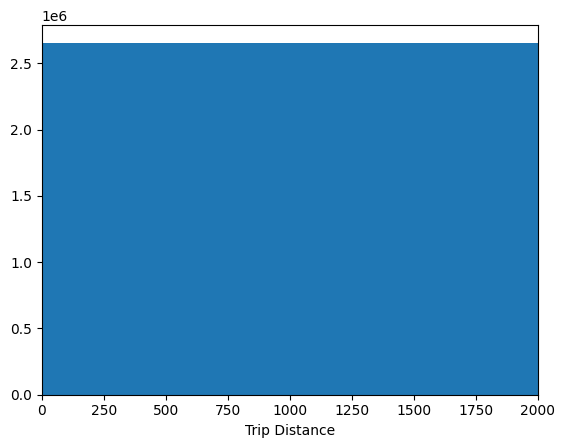

In [25]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
# check if there any passenger_count more than 6
print((df["passenger_count"] >= 7).sum())
# check if there are extreme values in fare_amount
#sns.boxplot(x=df["fare_amount"], whis=1.5) #there is one record with fare_amount > 140000
print((df["fare_amount"] > 14000).sum())
# check if trip_distance is zero and fare_amount is more than 300
tempdf = df.loc[(df["trip_distance"] == 0) & (df["fare_amount"] > 300)]
#tempdf[['trip_distance','fare_amount']].count() #there are 24 records where trip_distance is zero and fare_amount >300
# check if trip_distance and fare_amount are zero but pickup and drpoff zones are different
#print((tempdf["trip_distance"] == 0) & (tempdf["fare_amount"] > 300).sum())
tempdf = df.loc[((df["trip_distance"] == 0) & (df["fare_amount"] == 0)) & (df["PULocationID"] != df["DOLocationID"])]
#tempdf[['trip_distance','fare_amount','PULocationID','DOLocationID']].count() #there are 98 records where trip_distance is zero and fare_amount >300

# check if trip_distance is more than 250 miles
print((df['trip_distance'] > 250).sum())

# check if there are any entries with payment_type = 0
print((df['payment_type'] == 0).sum())

plt.hist(df["trip_distance"], bins=20) #trip_distance is going upto 2000: need to check if it is an outlier based on the busienss rule
plt.xlim(0, 2000)   # set x-axis range from 0 to 300
plt.xlabel("Trip Distance")
#plt.ylabel("Frequency")
plt.show()



**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [26]:
# remove passenger_count > 6
passengercountabnormal = df[df["passenger_count"] > 6]
passengercountabnormal["passenger_count"].count()#around 17 records where the passengercount is more than 6
df= df[df["passenger_count"] <= 6]
passengercountabnormal = df[df["passenger_count"] > 6]


In [27]:
# Continue with outlier handling:
#drop records where trip_distance = 0 and fare_amount >300
tempdf = df.loc[(df["trip_distance"] == 0) & (df["fare_amount"] > 300)]
tempdf[['trip_distance','fare_amount']].count()
df = df.drop(tempdf.index)
#Replace fare_amount with median for entries where dare_amount > 300

df.loc[df["fare_amount"] > 300, "fare_amount"] = df["fare_amount"].median()
#df[df["fare_amount"] > 300].count()
print((df['fare_amount'] > 300).sum())

#drop records where trip_distance = 0 and fare_amount = 0 and Pickup location is not same as drop location
tempdf = df.loc[((df["trip_distance"] == 0) & (df["fare_amount"] == 0)) & (df["PULocationID"] != df["DOLocationID"])]
df = df.drop(tempdf.index)


0


In [28]:
# Do any columns need standardising?

# check if trip_distance is more than 250 miles
tempdf = df.loc[(df["trip_distance"] > 250)] #there are 14 records where trip_distance >250 miles
print(tempdf['trip_distance'].sum())

##need to check if IQR needs to be used for standarizing values in trip_distance column

median_distance = df["trip_distance"].median()
print("Median trip_distance:", median_distance)

df.loc[df["trip_distance"] > 300, "trip_distance"] = median_distance

1120889.8300000003
Median trip_distance: 1.8


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [29]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'tip_amount',
 'tolls_amount',
 'total_amount',
 'congestion_surcharge',
 'date',
 'hour',
 'Airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

In [30]:
# Categorize variables into numerical and categorical


cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns:", cat_cols)

num_cols = df.select_dtypes(include=['int32','int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

print("Numeric Columns ", num_cols)
print("Categorical Columns ", cat_cols)
print("Datetime Columns ", datetime_cols)



Categorical columns: []
Numeric Columns  ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'tip_amount', 'tolls_amount', 'total_amount', 'congestion_surcharge', 'hour', 'Airport_fee']
Categorical Columns  []
Datetime Columns  ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'date']


**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

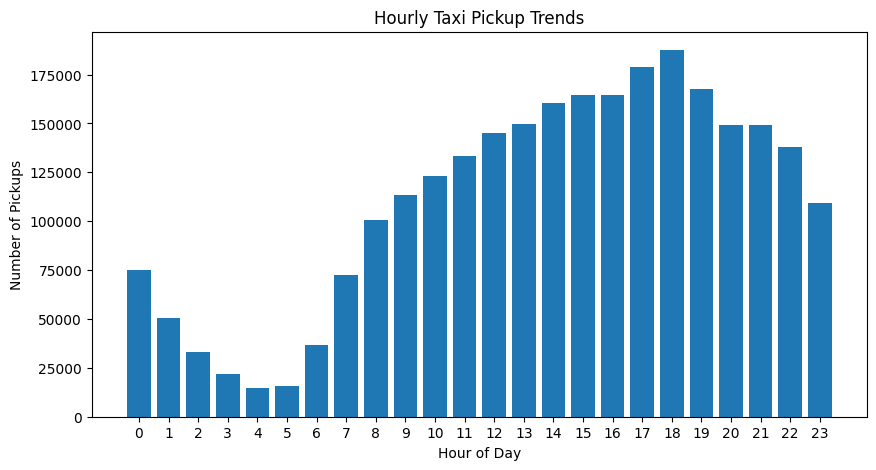

In [31]:
# Find and show the hourly trends in taxi pickups
df.head(5)
# Extract hour
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
hourly_counts = df["pickup_hour"].value_counts().sort_index()
#print(hourly_counts)

plt.figure(figsize=(10,5))
plt.bar(hourly_counts.index, hourly_counts.values)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.title("Hourly Taxi Pickup Trends")
plt.xticks(range(24))  # show all hours
plt.show()

#Taxi pickups are more between 5-7 pm

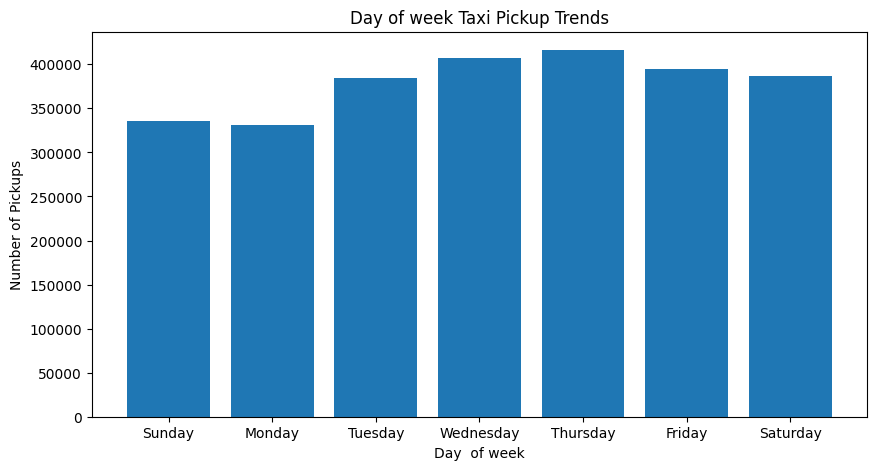

In [32]:
# Find and show the daily trends in taxi pickups (days of the week)

# Extract day of the week
order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
df["day_of_week"] = df["tpep_pickup_datetime"].dt.day_name()
day_of_week_counts = df["day_of_week"].value_counts().reindex(order)
#print(day_of_week_counts)

plt.figure(figsize=(10,5))
plt.bar(day_of_week_counts.index, day_of_week_counts.values)
plt.xlabel("Day  of week")
plt.ylabel("Number of Pickups")
plt.title("Day of week Taxi Pickup Trends")
plt.xticks(range(7))  # show all days
plt.show()

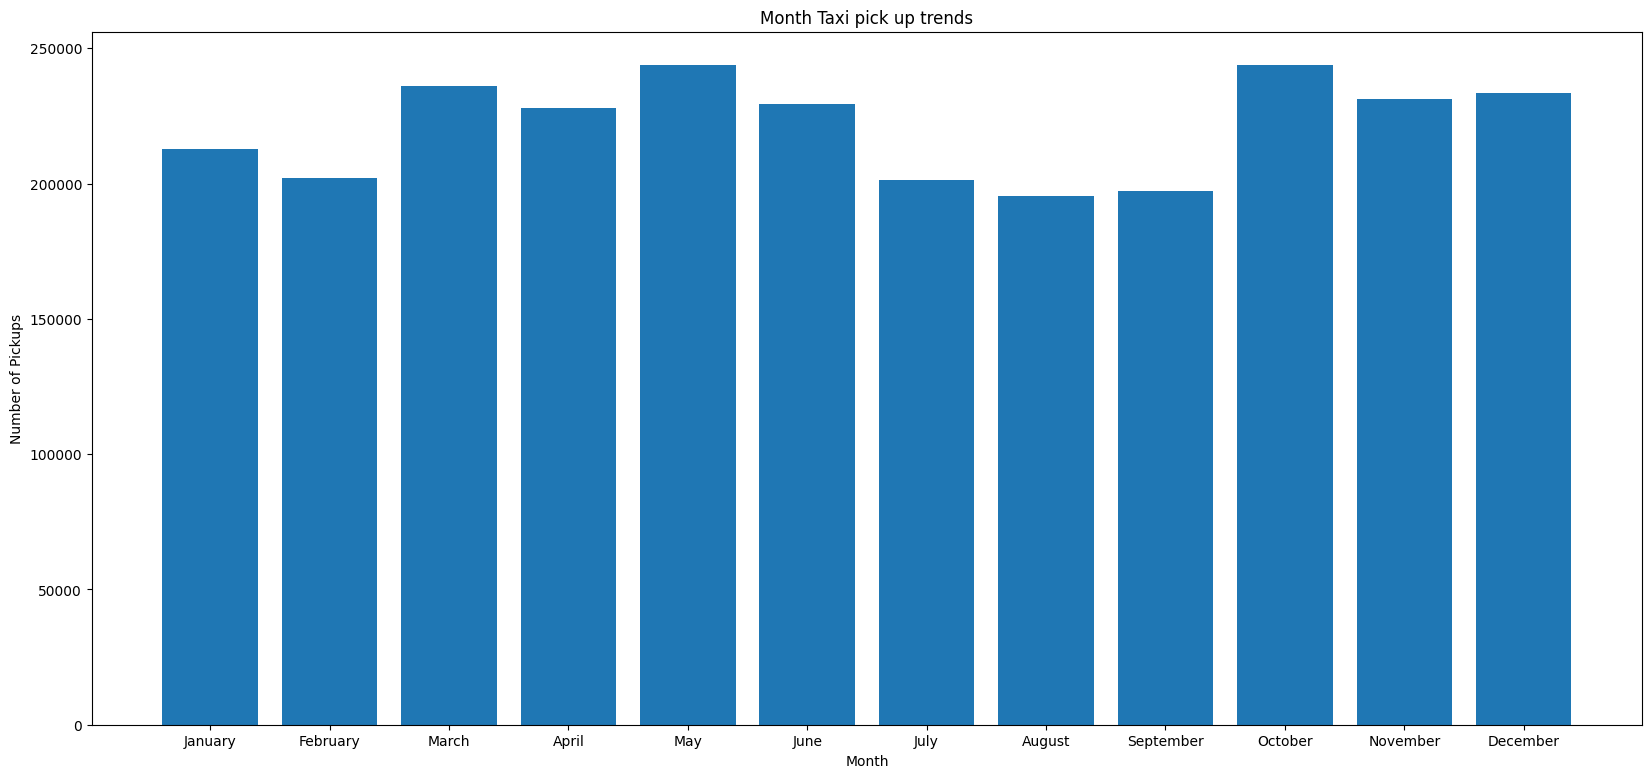

In [33]:
# Show the monthly trends in pickups

# Extract day of the week
order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df["month"] = df["tpep_pickup_datetime"].dt.month_name()
month_counts = df["month"].value_counts().reindex(order)
#print(month_counts)

plt.figure(figsize=(20,9))
plt.bar(month_counts.index, month_counts.values)
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.title("Month Taxi pick up trends")
plt.xticks(range(12))  # show all days
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [34]:
# Analyse the above parameters
fareamt = (df['fare_amount'] == 0 ).sum() #there are 459 records with fare_amount zero: none with negative value:
print("fare_amount_zero ", fareamt.sum())
tipamtzero = (df['tip_amount'] == 0).sum() #there are 328538 records with tip_amount zero: none with negative value:
print("tip_amount_zero ", tipamtzero.sum())
totalamtzero = (df['total_amount'] == 0).sum() #there are 200 records with total_amount zero: none with negative value:
print("total_amount_zero ", totalamtzero.sum())
tripdistzero = (df['trip_distance'] == 0).sum() #there are 18354 records with trip_distance zero: none with negative value:
print("trip_distance_zero ", tripdistzero.sum())

data = df.loc[df['fare_amount'] == 0]
data.info()
data[['fare_amount','RatecodeID','tip_amount','trip_distance','payment_type','extra','tolls_amount','total_amount']]

#they are zero because of a purpose: payment_type is either disupte/no charge or trip_distance is zero:
#there may be some error records, where trip_distance >0, total_amount > 0, fare_amount=0 and payment+Type=1

data1 = df.loc[(df['fare_amount'] == 0) & (df['trip_distance'] > 0) & (df['payment_type']==1)]
data1.head(5)

fare_amount_zero  815
tip_amount_zero  609669
total_amount_zero  358
trip_distance_zero  52629
<class 'pandas.core.frame.DataFrame'>
Index: 815 entries, 4367 to 2653700
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               815 non-null    int64         
 1   tpep_pickup_datetime   815 non-null    datetime64[us]
 2   tpep_dropoff_datetime  815 non-null    datetime64[us]
 3   passenger_count        815 non-null    int64         
 4   trip_distance          815 non-null    float64       
 5   RatecodeID             815 non-null    int64         
 6   PULocationID           815 non-null    int64         
 7   DOLocationID           815 non-null    int64         
 8   payment_type           815 non-null    int64         
 9   fare_amount            815 non-null    float64       
 10  extra                  815 non-null    float64       
 11  tip_amount             815

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,total_amount,congestion_surcharge,date,hour,Airport_fee,pickup_hour,day_of_week,month
222631,1,2023-08-02 14:28:40,2023-08-02 14:48:47,1,5.2,99,124,205,1,0.0,...,0.0,0.0,0.0,0.0,2023-08-02,14,0,14,Wednesday,August
387112,1,2023-08-28 16:09:10,2023-08-28 17:21:24,1,17.7,5,48,132,1,0.0,...,50.0,0.0,51.0,0.0,2023-08-28,16,0,16,Monday,August
434943,1,2023-02-04 15:08:24,2023-02-04 15:16:41,0,5.4,1,197,132,1,0.0,...,110.0,0.0,111.0,0.0,2023-02-04,15,0,15,Saturday,February
468175,1,2023-02-09 12:29:51,2023-02-09 12:30:23,1,2.1,5,145,145,1,0.0,...,0.0,0.0,0.0,0.0,2023-02-09,12,0,12,Thursday,February
500317,1,2023-02-13 17:12:05,2023-02-13 17:14:18,1,0.2,1,186,264,1,0.0,...,0.0,0.0,0.0,0.0,2023-02-13,17,0,17,Monday,February


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [35]:
# Create a df with non zero entries for the selected parameters.
# fare_amount, tip_amount, total_amount, and also trip_distance
#do not drop trip_distance as it does have some legitimate data
df = df[df["fare_amount"] > 0]
df = df[df["total_amount"] > 0]

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

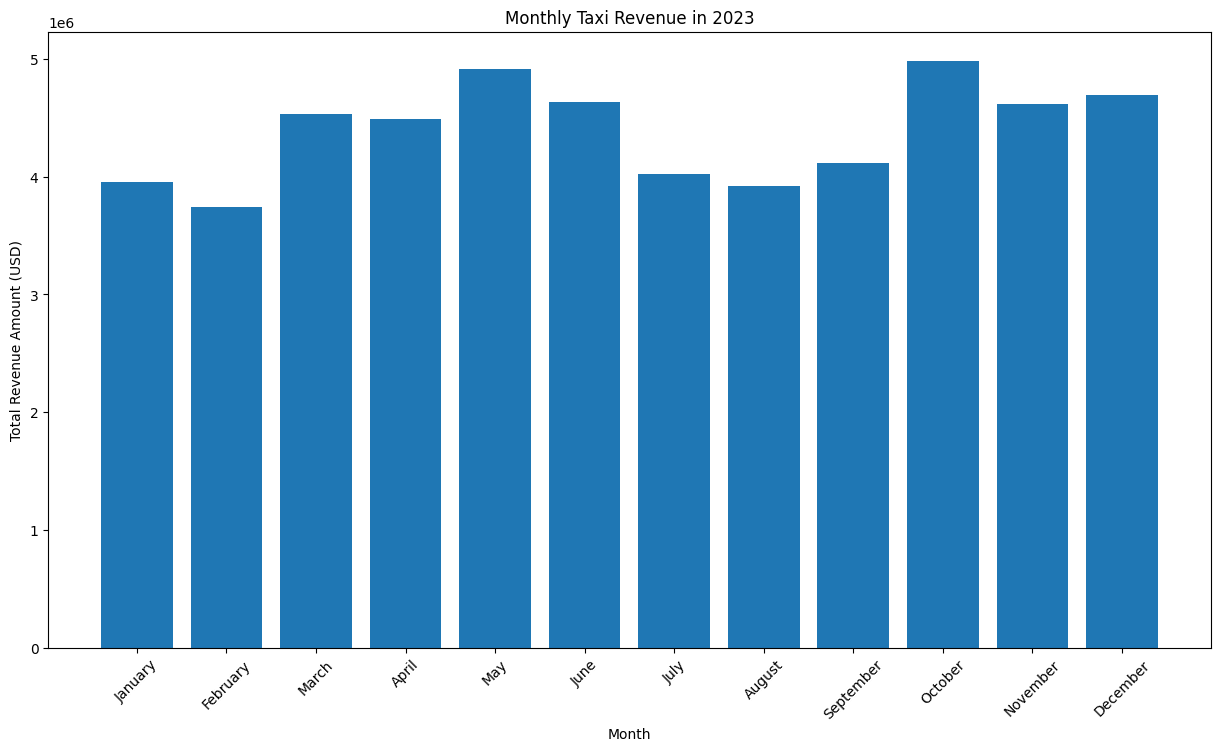

In [36]:
# Group data by month and analyse monthly revenueo
# Extract year-month (YYYY-MM format)
df_2023 = df[df["tpep_pickup_datetime"].dt.year==2023]
#print(monthly_revenue)
df_2023["month"] = df_2023["tpep_pickup_datetime"].dt.month_name()
monthly_revenue = df_2023.groupby("month")["fare_amount"].sum().reset_index()

# Define month order for proper sorting
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
monthly_revenue["month"] = pd.Categorical(monthly_revenue["month"], categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values("month")

plt.figure(figsize=(15,8))
#plt.hist(monthly_revenue["month"], monthly_revenue["fare_amount"], marker="o", color="steelblue")
plt.bar(monthly_revenue["month"], monthly_revenue["fare_amount"])
#plt.hist
plt.title("Monthly Taxi Revenue in 2023")
plt.xlabel("Month")
plt.ylabel("Total Revenue Amount (USD)")
plt.xticks(rotation=45)
plt.grid(False)
#plt.tight_layout()
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

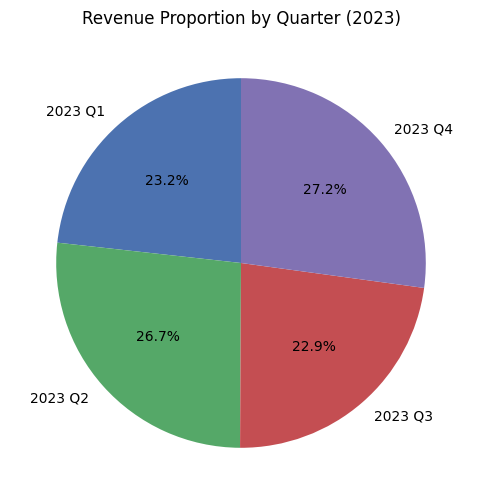

In [37]:
# Calculate proportion of each quarter
# Filter for 2023
df_2023 = df[df["tpep_pickup_datetime"].dt.year == 2023]

# Extract quarter
df_2023["quarter"] = df_2023["tpep_pickup_datetime"].dt.to_period("Q")

# Group by quarter and sum revenue
quarterly_revenue = df_2023.groupby("quarter")["fare_amount"].sum().reset_index()

# Format quarter labels with a space (e.g., "2023 Q1")
quarterly_revenue["quarter_label"] = quarterly_revenue["quarter"].astype(str).str.replace("Q", " Q")

# Calculate proportion
quarterly_revenue["proportion"] = quarterly_revenue["fare_amount"] / quarterly_revenue["fare_amount"].sum()

# Plot as pie chart
plt.figure(figsize=(6,6))
plt.pie(
    quarterly_revenue["fare_amount"],
    labels=quarterly_revenue["quarter_label"].astype(str),
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C72B0", "#55A868", "#C44E52", "#8172B3"]
)
plt.title("Revenue Proportion by Quarter (2023)")
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

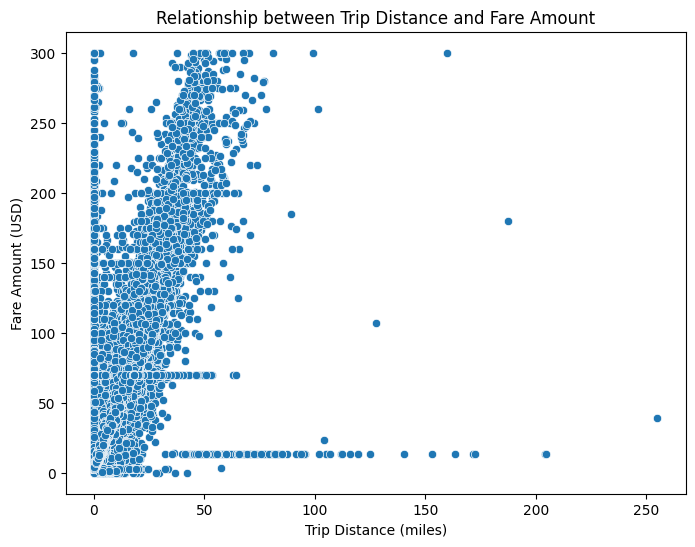

Correlation:  0.9027576396604426


In [38]:
# Show how trip fare is affected by distance
# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x="trip_distance", y="fare_amount", data=df)
plt.title("Relationship between Trip Distance and Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount (USD)")
plt.show()

correlation = df["trip_distance"].corr(df["fare_amount"])
print("Correlation: ", correlation)

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

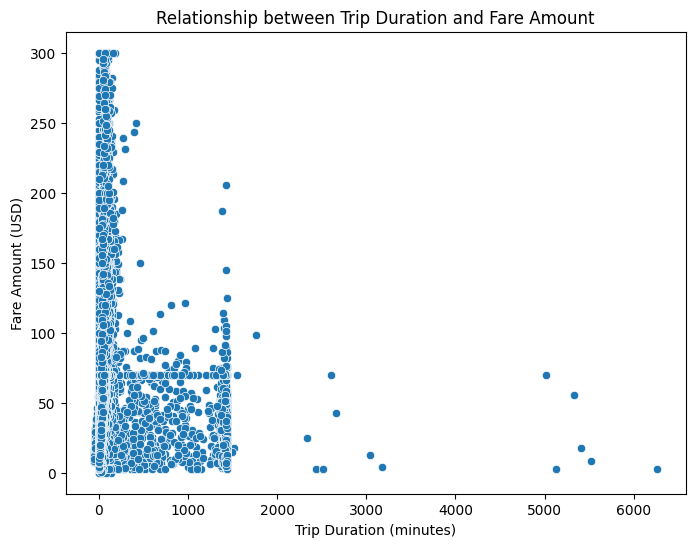

Correlation between trip_duration and fare_amount: 0.269295915188855


In [39]:
# Show relationship between fare and trip duration

import pandas as pd
# Ensure datetime type
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Trip duration in minutes
df["trip_duration"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60


plt.figure(figsize=(8,6))
sns.scatterplot(x="trip_duration", y="fare_amount", data=df)
plt.title("Relationship between Trip Duration and Fare Amount")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Fare Amount (USD)")
plt.show()

correlation = df["trip_duration"].corr(df["fare_amount"])
print("Correlation between trip_duration and fare_amount:", correlation)

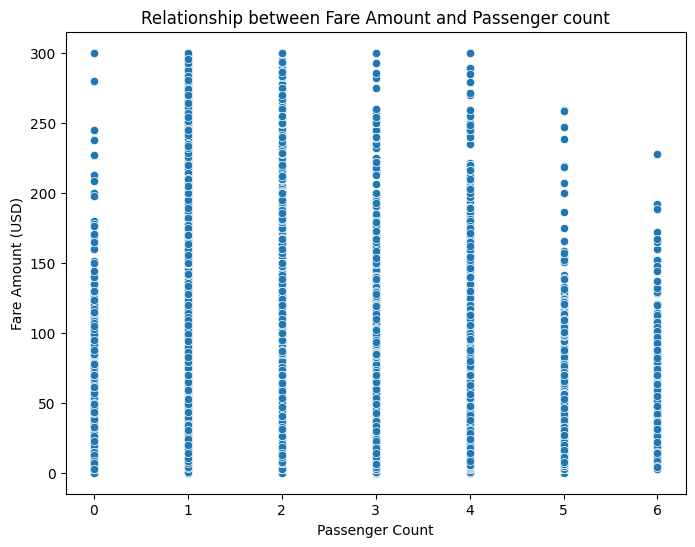

Correlation between passenger_count and fare_amount: 0.04423993666939133


In [40]:
# Show relationship between fare and number of passengers
#df.head(5)
plt.figure(figsize=(8,6))
sns.scatterplot(x="passenger_count", y="fare_amount", data=df)
plt.title("Relationship between Fare Amount and Passenger count")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount (USD)")
plt.show()

correlation = df["passenger_count"].corr(df["fare_amount"])
print("Correlation between passenger_count and fare_amount:", correlation)

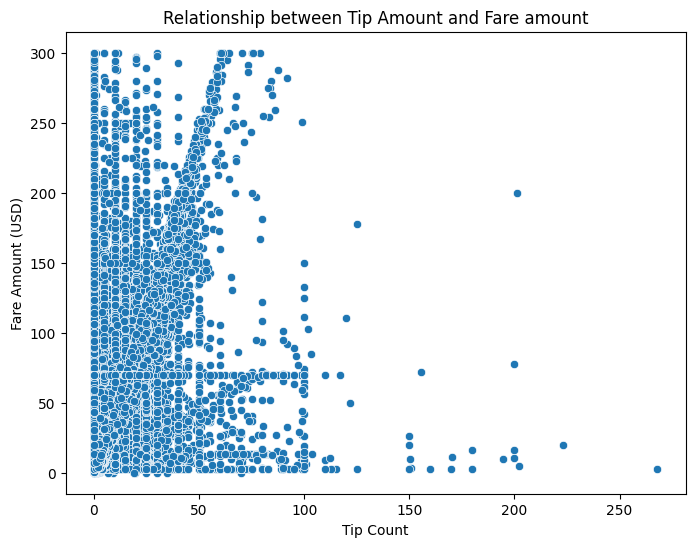

Correlation between passenger_count and fare_amount: 0.04423993666939133


In [41]:
# Show relationship between tip and trip distance
df.head()
plt.figure(figsize=(8,6))
sns.scatterplot(x="tip_amount", y="fare_amount", data=df)
plt.title("Relationship between Tip Amount and Fare amount")
plt.xlabel("Tip Count")
plt.ylabel("Fare Amount (USD)")
plt.show()

correlation = df["passenger_count"].corr(df["fare_amount"])
print("Correlation between passenger_count and fare_amount:", correlation)


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

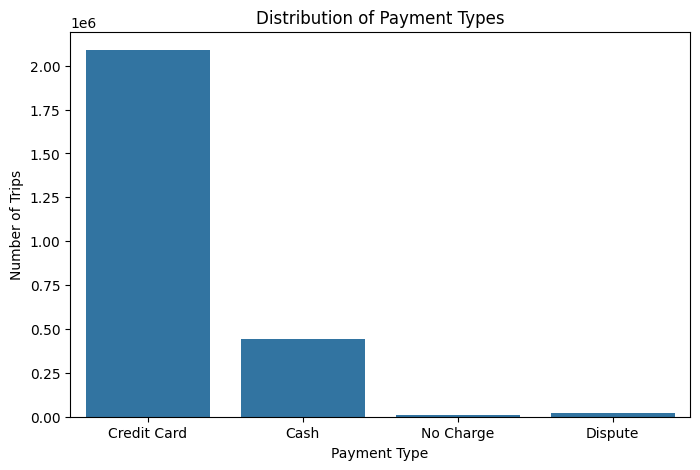

In [42]:
# Analyse the distribution of different payment types (payment_type).
payment_map = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute"
}

df["payment_type_label"] = df["payment_type"].map(payment_map)

payment_counts = df["payment_type_label"].value_counts()

plt.figure(figsize=(8,5))
sns.countplot(x="payment_type_label", data=df, order=payment_map.values())
plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [43]:
# import geopandas as gpd
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file('/content/drive/MyDrive/taxi_zones/taxi_zones.shp')# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

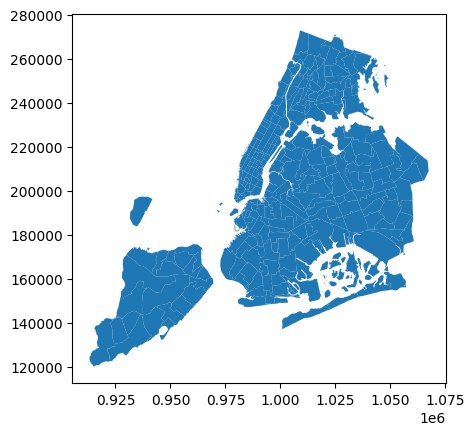

In [44]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [45]:
# Merge zones and trip records using locationID and PULocationID
#Using innter join merge data from "df" trip records and "zones" dataframe
#df.head(2)
#zones.head(2)
merged_df = pd.merge(df, zones, left_on="PULocationID", right_on="LocationID", how="inner")
print(merged_df)

         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0               2  2022-12-31 23:51:30   2022-12-31 23:56:06                1   
1               2  2023-01-01 00:07:18   2023-01-01 00:23:15                1   
2               2  2023-01-01 00:16:41   2023-01-01 00:21:46                2   
3               2  2023-01-01 00:14:03   2023-01-01 00:24:36                3   
4               2  2023-01-01 00:24:30   2023-01-01 00:29:55                1   
...           ...                  ...                   ...              ...   
2627578         2  2023-11-30 23:58:26   2023-12-01 00:22:37                5   
2627579         1  2023-11-30 23:18:30   2023-11-30 23:42:15                1   
2627580         2  2023-11-30 23:53:30   2023-12-01 00:01:06                1   
2627581         2  2023-11-30 23:19:38   2023-11-30 23:32:18                1   
2627582         1  2023-11-30 23:31:25   2023-11-30 23:42:59                2   

         trip_distance  Rat

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

   LocationID  trip_count
0           1         325
1           2           2
2           3          62
3           4        3268
4           5          21


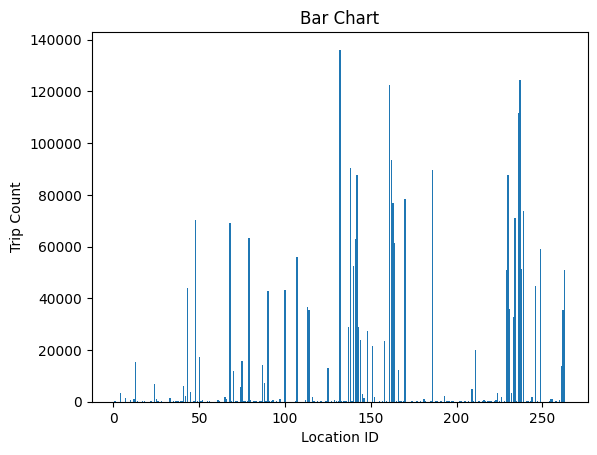

In [46]:
# Group data by location and calculate the number of trips

trips_by_location = merged_df.groupby("LocationID").size().reset_index(name="trip_count")
print(trips_by_location.head())

plt.bar(trips_by_location["LocationID"], trips_by_location["trip_count"])
plt.title("Bar Chart")
plt.xlabel("Location ID")
plt.ylabel("Trip Count")
plt.show()

**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [47]:
# Merge trip counts back to the zones GeoDataFrame

zones = pd.merge(zones, trips_by_location, left_on="LocationID", right_on="LocationID", how="inner")
zones.head(2)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",325
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

<Figure size 1200x800 with 0 Axes>

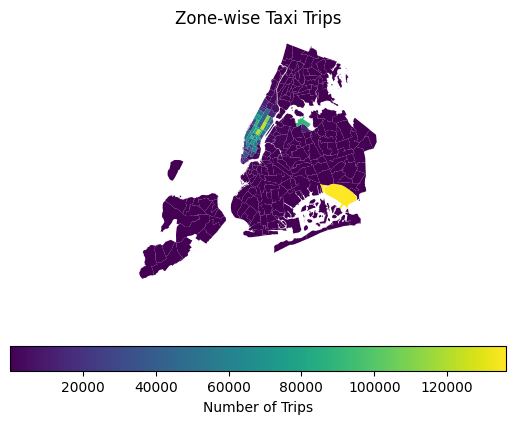

In [48]:
# Define figure and axis
plt.figure(figsize=(12,8))
zones.plot(column="trip_count", cmap="viridis", legend=True,
           legend_kwds={"label":"Number of Trips", "orientation":"horizontal"})
plt.title("Zone-wise Taxi Trips")
plt.axis("off")

# Plot the map and display it

plt.show()

In [55]:

# can you try displaying the zones DF sorted by the number of trips?
zonessorted = zones.sort_values(by="trip_count", ascending=True)
zonessorted.head(10)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
29,30,0.094510,0.000146,Broad Channel,30,Queens,"POLYGON ((1034013.272 163473.152, 1034866.459 ...",1
238,245,0.095983,0.000466,West Brighton,245,Staten Island,"POLYGON ((957085.564 172591.26, 957142.385 172...",1
83,84,0.233624,0.002074,Eltingville/Annadale/Prince's Bay,84,Staten Island,"POLYGON ((939754.454 131548.91, 939802.804 131...",1
26,27,0.202509,0.001341,Breezy Point/Fort Tilden/Riis Beach,27,Queens,"POLYGON ((1021692.969 147138.664, 1021883.624 ...",2
109,115,0.116169,0.000373,Grymes Hill/Clifton,115,Staten Island,"POLYGON ((961850.466 167915.309, 961831.926 16...",2
105,111,0.059931,0.000209,Green-Wood Cemetery,111,Brooklyn,"POLYGON ((985590.381 179611.82, 986202.162 179...",2
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2
150,156,0.144477,0.001052,Mariners Harbor,156,Staten Island,"MULTIPOLYGON (((934327.461 174416.463, 934330....",2
214,221,0.166218,0.000890,Stapleton,221,Staten Island,"POLYGON ((963349.728 171627.581, 963397.759 17...",3
166,172,0.118476,0.000658,New Dorp/Midland Beach,172,Staten Island,"POLYGON ((960204.812 146820.751, 960103.437 14...",3


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [49]:
# Find routes which have the slowest speeds at different times of the day

merged_df["tpep_pickup_datetime"] = pd.to_datetime(merged_df["tpep_pickup_datetime"])
merged_df["tpep_dropoff_datetime"] = pd.to_datetime(merged_df["tpep_dropoff_datetime"])

# Trip duration in hours
merged_df["trip_duration_hours"] = (merged_df["tpep_dropoff_datetime"] - merged_df["tpep_pickup_datetime"]).dt.total_seconds() / 3600

# Speed = distance / duration
merged_df["speed_mph"] = merged_df["trip_distance"] / merged_df["trip_duration_hours"]

merged_df["route"] = merged_df["zone"].astype(str)

# Group by route and hour, compute average speed
route_hour_speed = merged_df.groupby(["route", "hour"])["speed_mph"].mean().reset_index()

# Sort to find slowest routes per hour
slowest_routes = route_hour_speed.sort_values(by=["hour", "speed_mph"], ascending=[False, False])

print(slowest_routes.head(20))  # top 20 slowest route-hour combos

                                 route  hour   speed_mph
2637                   Lenox Hill West    23         inf
4563             Upper East Side North    23         inf
1278  East Concourse/Concourse Village    23  251.593964
693                           Canarsie    23  167.173493
4709          Washington Heights North    23  160.070438
629                     Bushwick North    23   96.234669
138                       Baisley Park    23   60.035842
3372                   Oakland Gardens    23   54.937236
519                         Bronx Park    23   52.235906
2179                   Highbridge Park    23   48.148238
235            Bay Terrace/Fort Totten    23   47.166341
2841                   Manhattan Beach    23   43.649779
3309                    Newark Airport    23   37.641574
221                          Bay Ridge    23   37.173136
2368                       JFK Airport    23   36.380824
4190         Springfield Gardens South    23   34.154541
1302                     East E

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

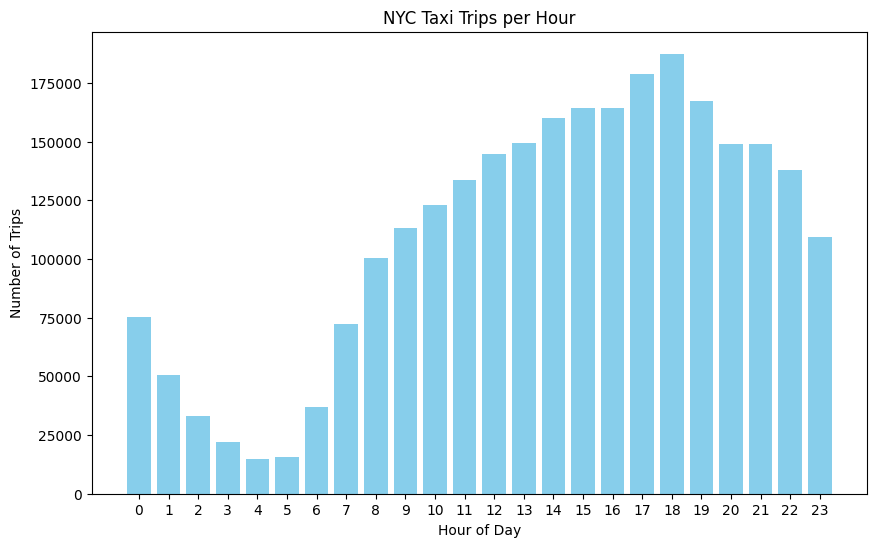

In [50]:
# Visualise the number of trips per hour and find the busiest hour
df.head()
trips_per_hour = df.groupby("hour").size().reset_index(name="trip_count")

plt.figure(figsize=(10,6))
plt.bar(trips_per_hour["hour"], trips_per_hour["trip_count"], color="skyblue")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("NYC Taxi Trips per Hour")
plt.xticks(range(24))  # show all hours 0–23
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [51]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
#sample_fraction =

# Ensure datetime type
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# Extract hour (0–23)
df["hour"] = df["tpep_pickup_datetime"].dt.hour

# Count trips per hour
trips_per_hour = df.groupby("hour").size().reset_index(name="trip_count")

# Sort by trip_count descending
top5_hours = trips_per_hour.sort_values(by="trip_count", ascending=False).head(5)

print(top5_hours)

    hour  trip_count
18    18      187460
17    17      178958
19    19      167457
16    16      164466
15    15      164313


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

   hour  is_weekend  trip_count
0     0       False       37326
1     0        True       37822
2     1       False       19006
3     1        True       31413
4     2       False       10311


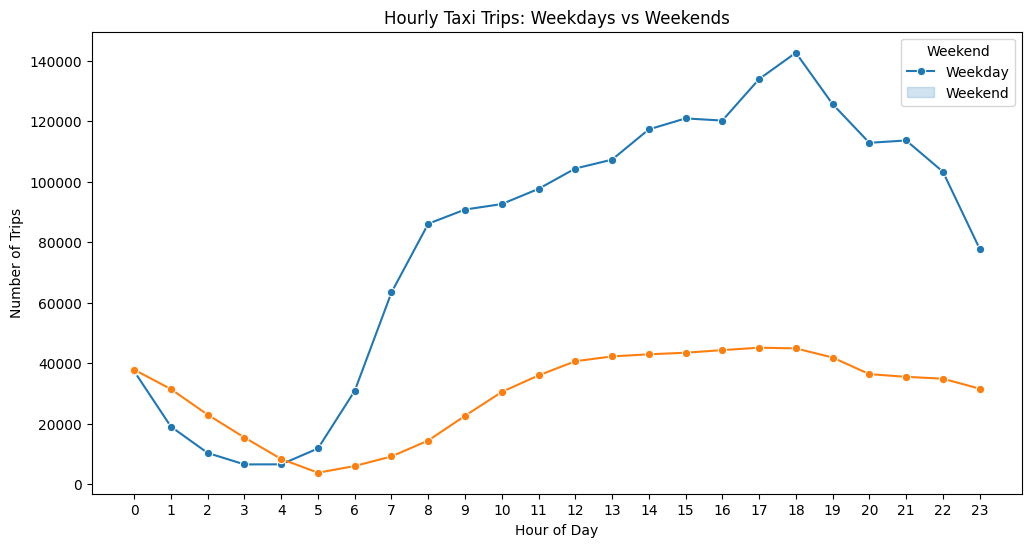

In [53]:
# Compare traffic trends for the week days and weekends
# Ensure datetime type
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# Extract hour and day of week
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek

# Weekdays: Mon–Fri (0–4), Weekends: Sat–Sun (5–6)
df["is_weekend"] = df["dayofweek"].isin([5,6])

# Group by hour and weekend flag
hourly_counts = df.groupby(["hour","is_weekend"]).size().reset_index(name="trip_count")

print(hourly_counts.head())

plt.figure(figsize=(12,6))
sns.lineplot(data=hourly_counts, x="hour", y="trip_count", hue="is_weekend", marker="o")
plt.title("Hourly Taxi Trips: Weekdays vs Weekends")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.legend(title="Weekend", labels=["Weekday","Weekend"])
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

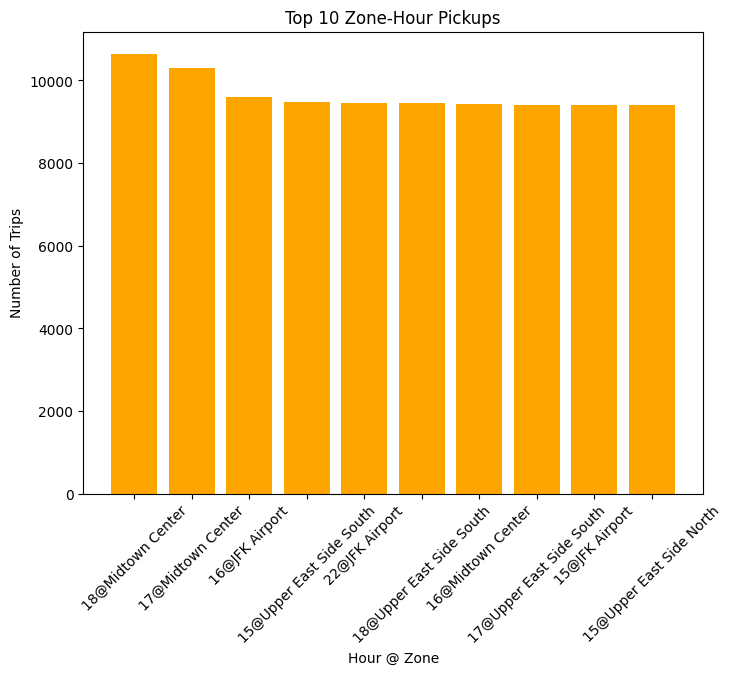

In [54]:
# Find top 10 pickup and dropoff zones

# Count trips grouped by pickup zone and hour
pickup_zone_hour_counts = df.groupby(["PULocationID","hour"]).size().reset_index(name="trip_count")

top10_pickup_zone_hours = pickup_zone_hour_counts.sort_values(by="trip_count", ascending=False).head(10)
#print(top10_pickup_zone_hours)
#zones.head(5)

top10_pickup_zone_by_hour = pd.merge(top10_pickup_zone_hours, zones, left_on="PULocationID", right_on="LocationID", how="inner")
top10_pickup_zone_by_hour.head(10)

plt.figure(figsize=(8,6))
plt.bar(top10_pickup_zone_by_hour["hour"].astype(str) + "@" + top10_pickup_zone_by_hour["zone"].astype(str),top10_pickup_zone_by_hour["trip_count_x"].astype(int), color="orange")
plt.xticks(rotation=45)
plt.xlabel("Hour @ Zone")
plt.ylabel("Number of Trips")
plt.title("Top 10 Zone-Hour Pickups")
plt.show()


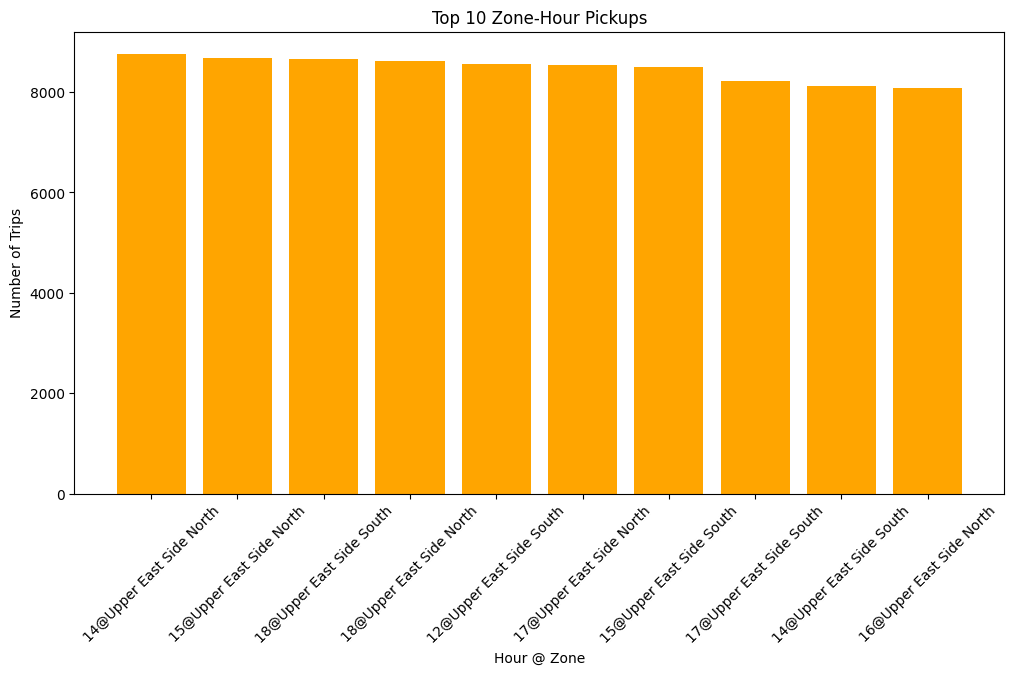

In [55]:
# Find top 10 pickup and dropoff zones
# Count trips grouped by drop zone and hour
drop_zone_hour_counts = df.groupby(["DOLocationID","hour"]).size().reset_index(name="trip_count")

top10_drop_zone_hours = drop_zone_hour_counts.sort_values(by="trip_count", ascending=False).head(10)
#print(top10_drop_zone_hours)

top10_drop_zone_by_hour = pd.merge(top10_drop_zone_hours, zones, left_on="DOLocationID", right_on="LocationID", how="inner")
#top10_drop_zone_by_hour.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_drop_zone_by_hour["hour"].astype(str) + "@" + top10_drop_zone_by_hour["zone"].astype(str),top10_drop_zone_by_hour["trip_count_x"].astype(int), color="orange")
plt.xticks(rotation=45)
plt.xlabel("Hour @ Zone")
plt.ylabel("Number of Trips")
plt.title("Top 10 Zone-Hour Pickups")
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [56]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
#needs to be revisted:

pickup_counts = df.groupby("PULocationID").size().reset_index(name="pickup_count")
dropoff_counts = df.groupby("DOLocationID").size().reset_index(name="dropoff_count")

zone_counts = pickup_counts.merge(dropoff_counts,
                                  left_on="PULocationID",
                                  right_on="DOLocationID",
                                  how="outer")

# Clean up column names
zone_counts["LocationID"] = zone_counts["PULocationID"].fillna(zone_counts["DOLocationID"])
zone_counts = zone_counts[["LocationID","pickup_count","dropoff_count"]].fillna(0)

zone_counts["pickup_dropoff_ratio"] = zone_counts["pickup_count"] / zone_counts["dropoff_count"].replace(0,1)

top10 = zone_counts.sort_values("pickup_dropoff_ratio", ascending=False).head(10)
bottom10 = zone_counts.sort_values("pickup_dropoff_ratio", ascending=True).head(10)

top10 = pd.merge(top10, zones, left_on="LocationID", right_on="LocationID", how="inner")
bottom10 = pd.merge(bottom10, zones, left_on="LocationID", right_on="LocationID", how="inner")

print("Top 10 Zones (High Pickup/Dropoff Ratio):")
print(top10[['zone','LocationID','pickup_count','dropoff_count','pickup_dropoff_ratio']].sort_values(by="pickup_dropoff_ratio", ascending=False))

print("\nBottom 10 Zones (Low Pickup/Dropoff Ratio):")
bottom10[['zone','LocationID','pickup_count','dropoff_count','pickup_dropoff_ratio']]


Top 10 Zones (High Pickup/Dropoff Ratio):
                           zone  LocationID  pickup_count  dropoff_count  \
0                 East Elmhurst        70.0       11770.0         1473.0   
1                   JFK Airport       132.0      136153.0        31921.0   
2                 Rikers Island       199.0           4.0            0.0   
3             LaGuardia Airport       138.0       90398.0        34268.0   
4  Penn Station/Madison Sq West       186.0       89760.0        57942.0   
5       Greenwich Village South       114.0       35321.0        25420.0   
6                  Central Park        43.0       43802.0        32134.0   
7                  West Village       249.0       58938.0        44039.0   
8                  Midtown East       162.0       93465.0        75174.0   
9                Midtown Center       161.0      122471.0       103163.0   

   pickup_dropoff_ratio  
0              7.990496  
1              4.265311  
2              4.000000  
3              2.

,zone,LocationID,pickup_count,dropoff_count,pickup_dropoff_ratio
0,West Brighton,245.0,1.0,41.0,0.024390
1,Newark Airport,1.0,325.0,8088.0,0.040183
2,Broad Channel,30.0,1.0,24.0,0.041667
3,Breezy Point/Fort Tilden/Riis Beach,27.0,2.0,45.0,0.044444
4,Mariners Harbor,156.0,2.0,41.0,0.048780
5,Windsor Terrace,257.0,57.0,1120.0,0.050893
6,Stapleton,221.0,3.0,53.0,0.056604


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [57]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_df = df[(df["hour"] >= 23) | (df["hour"] <= 5)]
# Pickups per zone during night
pickup_counts = night_df.groupby("PULocationID").size().reset_index(name="pickup_count")

# Dropoffs per zone during night
dropoff_counts = night_df.groupby("DOLocationID").size().reset_index(name="dropoff_count")

zone_counts = pickup_counts.merge(dropoff_counts,
                                  left_on="PULocationID",
                                  right_on="DOLocationID",
                                  how="outer")

zone_counts["LocationID"] = zone_counts["PULocationID"].fillna(zone_counts["DOLocationID"])
zone_counts = zone_counts[["LocationID","pickup_count","dropoff_count"]].fillna(0)

# Sort by combined traffic
zone_counts["total_night_trips"] = zone_counts["pickup_count"] + zone_counts["dropoff_count"]
high_traffic_zones = zone_counts.sort_values("total_night_trips", ascending=False).head(10)

high_traffic_zones = pd.merge(high_traffic_zones, zones, left_on="LocationID", right_on="LocationID", how="inner")

high_traffic_zones[['LocationID','zone','pickup_count','dropoff_count','total_night_trips']]


,LocationID,zone,pickup_count,dropoff_count,total_night_trips
0,79.0,East Village,23055.0,12234,35289.0
1,249.0,West Village,18451.0,7186,25637.0
2,48.0,Clinton East,15118.0,10151,25269.0
3,132.0,JFK Airport,20318.0,2943,23261.0
4,148.0,Lower East Side,14243.0,6488,20731.0
5,230.0,Times Sq/Theatre District,11882.0,6779,18661.0
6,68.0,East Chelsea,8965.0,8495,17460.0
7,114.0,Greenwich Village South,12919.0,3796,16715.0
8,107.0,Gramercy,8272.0,8353,16625.0
9,186.0,Penn Station/Madison Sq West,9987.0,5539,15526.0


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

  time_period  fare_amount      share
0         Day  46079495.15  87.565332
1       Night   6543493.90  12.434668


([<matplotlib.patches.Wedge at 0x7b10617e8ad0>,
 [Text(0.5099254792674686, -0.974667125532529, 'Day'),
  Text(-0.5099248673392242, 0.9746674456803586, 'Night')],
 [Text(0.27814117050952825, -0.5316366139268339, '87.6%'),
  Text(-0.2781408367304859, 0.5316367885529227, '12.4%')])

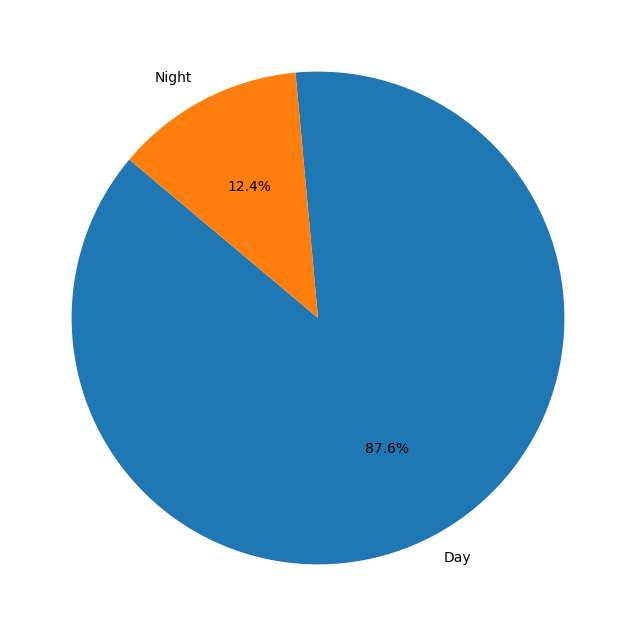

In [58]:
# Filter for night hours (11 PM to 5 AM)

# Night: 11 PM–5 AM, Day: 6 AM–10 PM
df["time_period"] = df["hour"].apply(lambda h: "Night" if (h >= 23 or h <= 5) else "Day")

# Assuming 'fare_amount' represents revenue
revenue_by_period = df.groupby("time_period")["fare_amount"].sum().reset_index()

# Calculate share
total_revenue = revenue_by_period["fare_amount"].sum()
revenue_by_period["share"] = revenue_by_period["fare_amount"] / total_revenue * 100

print(revenue_by_period)
data = revenue_by_period["share"].tolist()
labels = revenue_by_period["time_period"].tolist()

plt.figure(figsize=(8,8))
plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=140)



##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

   passenger_count       mean    median    count
0                1  10.840600  7.153846  1973522
1                2   6.633149  3.519737   384277
2                3   3.963821  2.374429    95531
3                4   4.381642  1.769231    52721
4                5   1.673775  1.416667    33330
5                6   1.417559  1.196970    21963


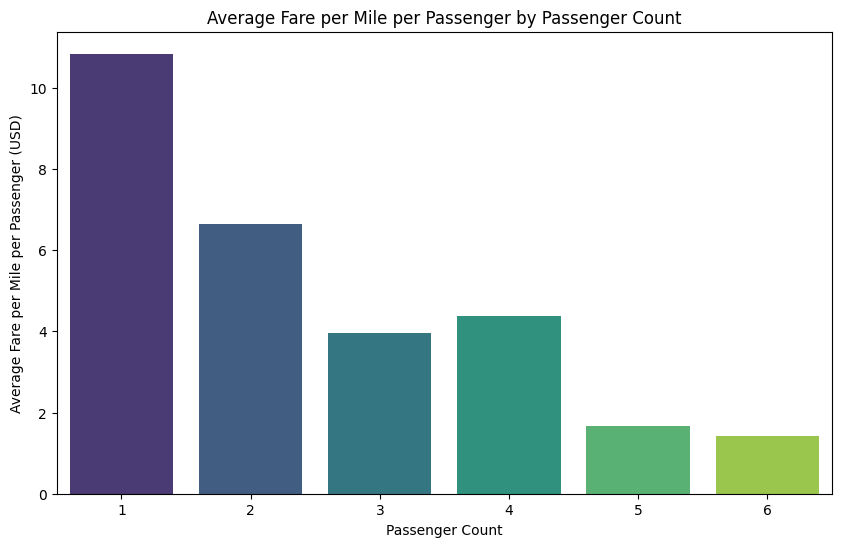

In [59]:
# Analyse the fare per mile per passenger for different passenger counts

dfnew = df[(df["trip_distance"] > 0) & (df["passenger_count"] > 0)]
# Calculate fare per mile per passenger
dfnew["fare_per_mile_per_passenger"] = dfnew["fare_amount"] / (dfnew["trip_distance"] * dfnew["passenger_count"])

fare_stats = dfnew.groupby("passenger_count")["fare_per_mile_per_passenger"].agg(["mean", "median", "count"]).reset_index()
print(fare_stats)

plt.figure(figsize=(10,6))
sns.barplot(data=fare_stats, x="passenger_count", y="mean", palette="viridis")
plt.title("Average Fare per Mile per Passenger by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Average Fare per Mile per Passenger (USD)")
plt.show()


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

0    10.858553
1    11.076348
2    11.159440
3    11.467063
4    11.044775
5    11.193720
6    12.324566
Name: fare_per_mile, dtype: float64
0     10.090250
1     11.221357
2     10.629960
3     12.102870
4     13.687250
5     14.280178
6     11.443874
7      9.815710
8     10.163806
9     10.517822
10    10.555035
11    11.134043
12    11.840704
13    12.022726
14    11.642582
15    12.827267
16    13.607528
17    12.086641
18    11.475743
19    11.689007
20    10.021456
21     9.642939
22    10.079838
23    10.514275
Name: fare_per_mile, dtype: float64


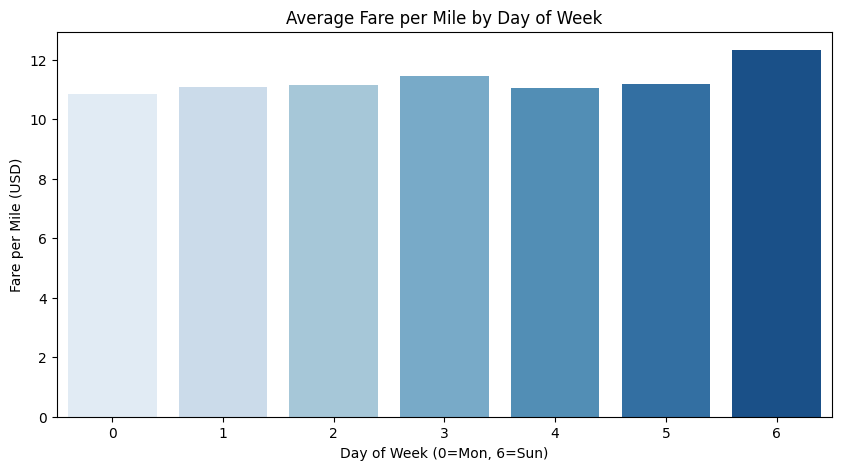

In [60]:
# df = df[df["trip_distance"] > 0]

# Fare per mile
df = df[df["trip_distance"] > 0]
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]
#print(df["fare_per_mile"])
df["pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["dayofweek"] = df["pickup_datetime"].dt.dayofweek   # Monday=0, Sunday=6
df["hournew"] = df["pickup_datetime"].dt.hour

fare_by_day = df.groupby("dayofweek")["fare_per_mile"].mean().reset_index()
print(fare_by_day["fare_per_mile"])

fare_by_hour = df.groupby("hournew")["fare_per_mile"].mean().reset_index()
print(fare_by_hour["fare_per_mile"])

# Average fare per mile by day
plt.figure(figsize=(10,5))
sns.barplot(data=fare_by_day, x="dayofweek", y="fare_per_mile", palette="Blues")
plt.title("Average Fare per Mile by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Fare per Mile (USD)")
plt.show()




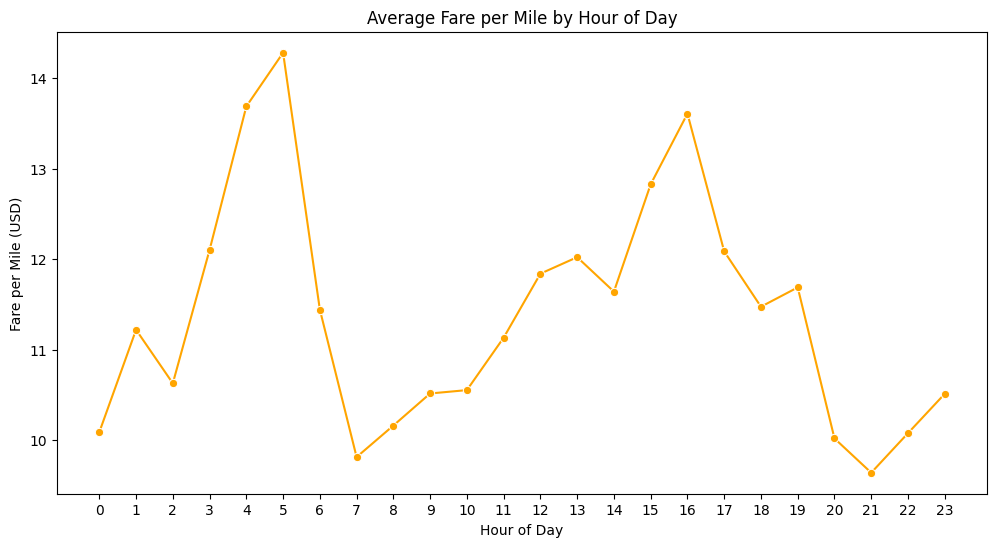

In [61]:
# Average fare per mile by hour
plt.figure(figsize=(12,6))
sns.lineplot(data=fare_by_hour, x="hournew", y="fare_per_mile", marker="o", color="orange")
plt.title("Average Fare per Mile by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fare per Mile (USD)")
plt.xticks(range(24))
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

   VendorID  fare_per_mile
0         1       8.124343
1         2      12.413120
2         6       6.494216


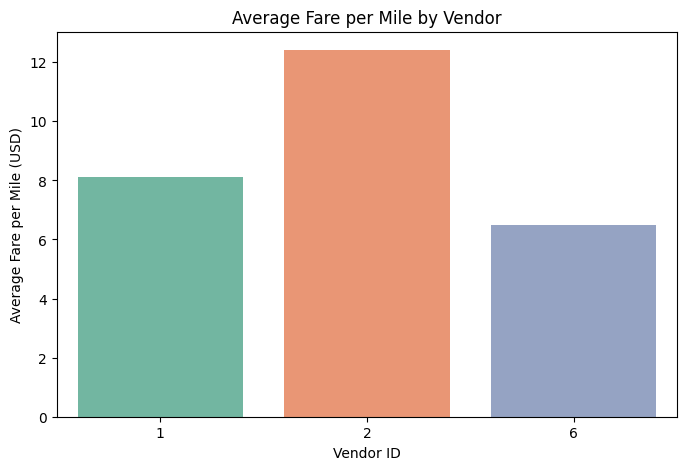

In [62]:
# Compare fare per mile for different vendors

# Ensure valid trips
df = df[df["trip_distance"] > 0]

# Fare per mile
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]

fare_by_vendor = df.groupby("VendorID")["fare_per_mile"].mean().reset_index()
print(fare_by_vendor)

plt.figure(figsize=(8,5))
sns.barplot(data=fare_by_vendor, x="VendorID", y="fare_per_mile", palette="Set2")
plt.title("Average Fare per Mile by Vendor")
plt.xlabel("Vendor ID")
plt.ylabel("Average Fare per Mile (USD)")
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


   VendorID distance_tier  fare_per_mile
0         1     0–2 miles       9.911032
1         1     2–5 miles       6.381897
2         1      5+ miles       4.422232
3         2     0–2 miles      18.147569
4         2     2–5 miles       6.540131
5         2      5+ miles       4.487782
6         6     0–2 miles      37.406077
7         6     2–5 miles       7.950157
8         6      5+ miles       4.400414


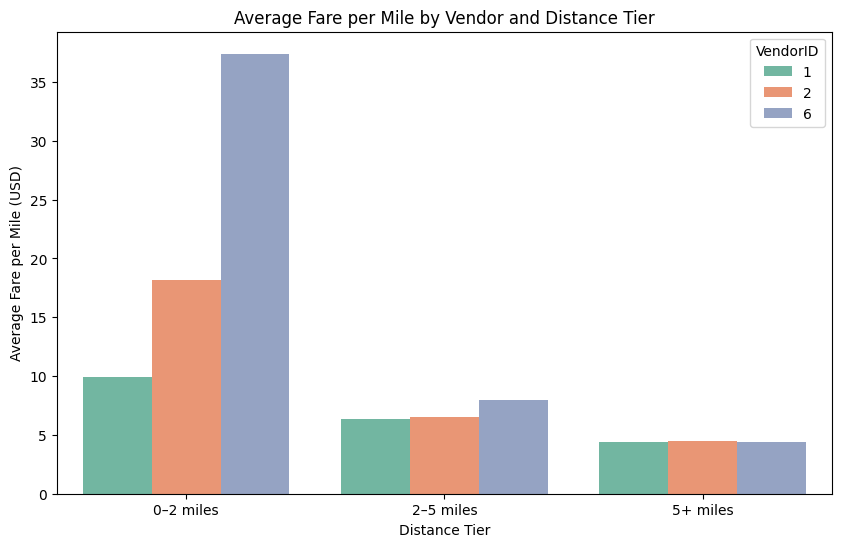

In [63]:
# Defining distance tiers
# Ensure valid trips
df = df[(df["trip_distance"] > 0) & (df["fare_amount"] > 0)]

# Fare per mile
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]


def tier(distance):
    if distance <= 2:
        return "0–2 miles"
    elif distance <= 5:
        return "2–5 miles"
    else:
        return "5+ miles"

df["distance_tier"] = df["trip_distance"].apply(tier)

fare_by_vendor_tier = (
    df.groupby(["VendorID", "distance_tier"])["fare_per_mile"]
      .mean()
      .reset_index()
)

print(fare_by_vendor_tier)

plt.figure(figsize=(10,6))
sns.barplot(data=fare_by_vendor_tier, x="distance_tier", y="fare_per_mile", hue="VendorID", palette="Set2")
plt.title("Average Fare per Mile by Vendor and Distance Tier")
plt.xlabel("Distance Tier")
plt.ylabel("Average Fare per Mile (USD)")
plt.show()


**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

  distance_tier    tip_pct
0     0–2 miles  22.363237
1     2–5 miles  18.624650
2      5+ miles  17.282058
   passenger_count    tip_pct
0                0  19.969179
1                1  20.731251
2                2  19.734670
3                3  19.095418
4                4  17.479451
5                5  20.502779
6                6  20.565404
    hour    tip_pct
0      0  20.291642
1      1  20.437664
2      2  20.349324
3      3  20.180842
4      4  18.057342
5      5  17.520045
6      6  18.400728
7      7  19.517575
8      8  19.911707
9      9  19.692136
10    10  19.256663
11    11  19.170068
12    12  19.138848
13    13  19.034283
14    14  18.978406
15    15  18.976416
16    16  20.786073
17    17  23.544321
18    18  22.074482
19    19  22.047097
20    20  21.400932
21    21  21.411699
22    22  21.097403
23    23  20.483128


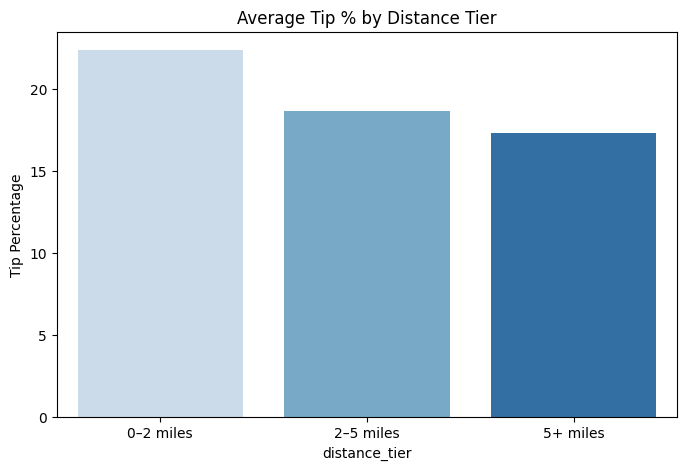

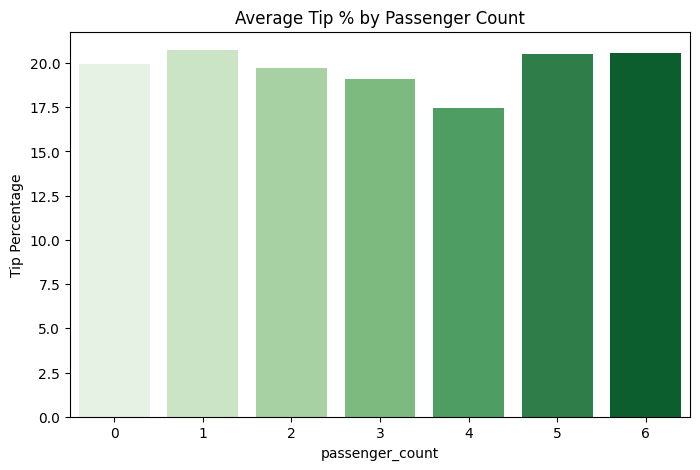

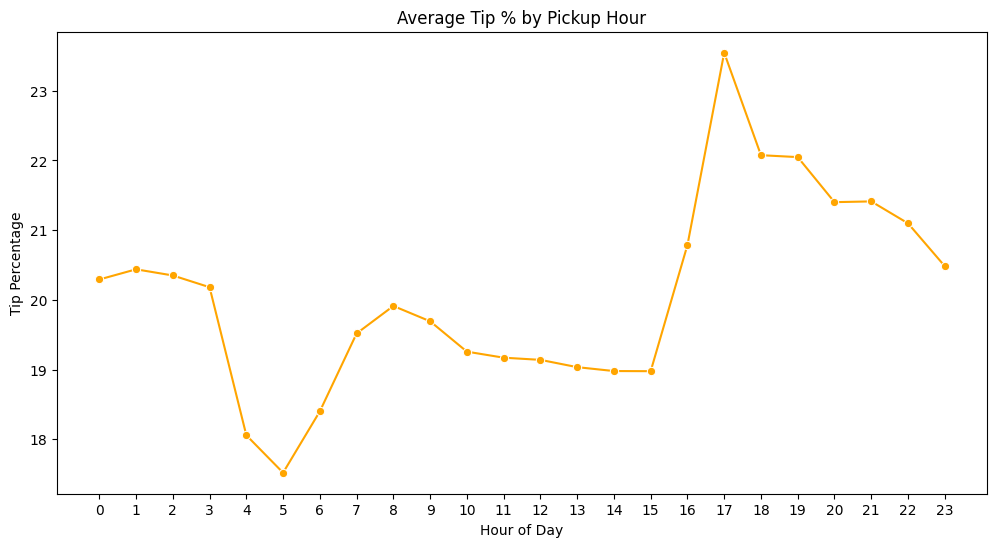

In [64]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df = df[df["fare_amount"] > 0]

# Tip percentage relative to fare
df["tip_pct"] = (df["tip_amount"] / df["fare_amount"]) * 100

# Define distance tiers
def distance_tier(d):
    if d <= 2:
        return "0–2 miles"
    elif d <= 5:
        return "2–5 miles"
    else:
        return "5+ miles"

df["distance_tier"] = df["trip_distance"].apply(distance_tier)

tip_by_distance = df.groupby("distance_tier")["tip_pct"].mean().reset_index()
print(tip_by_distance)

tip_by_passenger = df.groupby("passenger_count")["tip_pct"].mean().reset_index()
print(tip_by_passenger)

df["pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["hour"] = df["pickup_datetime"].dt.hour

tip_by_hour = df.groupby("hour")["tip_pct"].mean().reset_index()
print(tip_by_hour)

# Tip % by distance
plt.figure(figsize=(8,5))
sns.barplot(data=tip_by_distance, x="distance_tier", y="tip_pct", palette="Blues")
plt.title("Average Tip % by Distance Tier")
plt.ylabel("Tip Percentage")
plt.show()

# Tip % by passenger count
plt.figure(figsize=(8,5))
sns.barplot(data=tip_by_passenger, x="passenger_count", y="tip_pct", palette="Greens")
plt.title("Average Tip % by Passenger Count")
plt.ylabel("Tip Percentage")
plt.show()

# Tip % by pickup hour
plt.figure(figsize=(12,6))
sns.lineplot(data=tip_by_hour, x="hour", y="tip_pct", marker="o", color="orange")
plt.title("Average Tip % by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Tip Percentage")
plt.xticks(range(24))
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [65]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
#df = df[df["fare_amount"] > 0]  # avoid division by zero
df["tip_pct"] = (df["tip_amount"] / df["fare_amount"]) * 100

low_tip = df[df["tip_pct"] < 10]
high_tip = df[df["tip_pct"] > 25]

comparison = {
    "avg_distance": [low_tip["trip_distance"].mean(), high_tip["trip_distance"].mean()],
    "avg_passengers": [low_tip["passenger_count"].mean(), high_tip["passenger_count"].mean()],
    "avg_fare": [low_tip["fare_amount"].mean(), high_tip["fare_amount"].mean()],
    "avg_tip_pct": [low_tip["tip_pct"].mean(), high_tip["tip_pct"].mean()]
}

comparison_df = pd.DataFrame(comparison, index=["Tip < 10%", "Tip > 25%"])
print(comparison_df)

low_tip_by_hour = low_tip.groupby(low_tip["tpep_pickup_datetime"].dt.hour)["tip_pct"].mean().sort_values(ascending=True)
high_tip_by_hour = high_tip.groupby(high_tip["tpep_pickup_datetime"].dt.hour)["tip_pct"].mean().sort_values(ascending=True)

print("Low Tip % by Hour:\n", low_tip_by_hour)
print("High Tip % by Hour:\n", high_tip_by_hour)


           avg_distance  avg_passengers   avg_fare  avg_tip_pct
Tip < 10%      3.937632        1.399391  21.595328     1.087983
Tip > 25%      2.315810        1.343749  14.443345    32.404203
Low Tip % by Hour:
 tpep_pickup_datetime
4     0.818585
5     0.835012
10    0.884975
13    0.888474
11    0.891805
12    0.908108
14    0.924413
16    1.006647
15    1.026010
6     1.033110
9     1.090615
17    1.151515
18    1.169099
19    1.188029
20    1.189150
3     1.195461
21    1.215686
2     1.245922
23    1.280091
7     1.281011
22    1.285303
0     1.294188
1     1.296896
8     1.320835
Name: tip_pct, dtype: float64
High Tip % by Hour:
 tpep_pickup_datetime
15    31.148489
14    31.174271
12    31.184909
10    31.191634
8     31.202256
11    31.233742
9     31.241136
13    31.248851
7     31.409832
22    31.745018
21    31.826892
23    31.928495
20    32.105794
0     32.251510
1     32.496783
6     32.547166
2     32.988279
16    33.123878
18    33.288400
19    33.344097
5     33.413823

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

   dayofweek  hour  passenger_count
0          0     0             7421
1          0     1             3886
2          0     2             1974
3          0     3             1506
4          0     4             1591


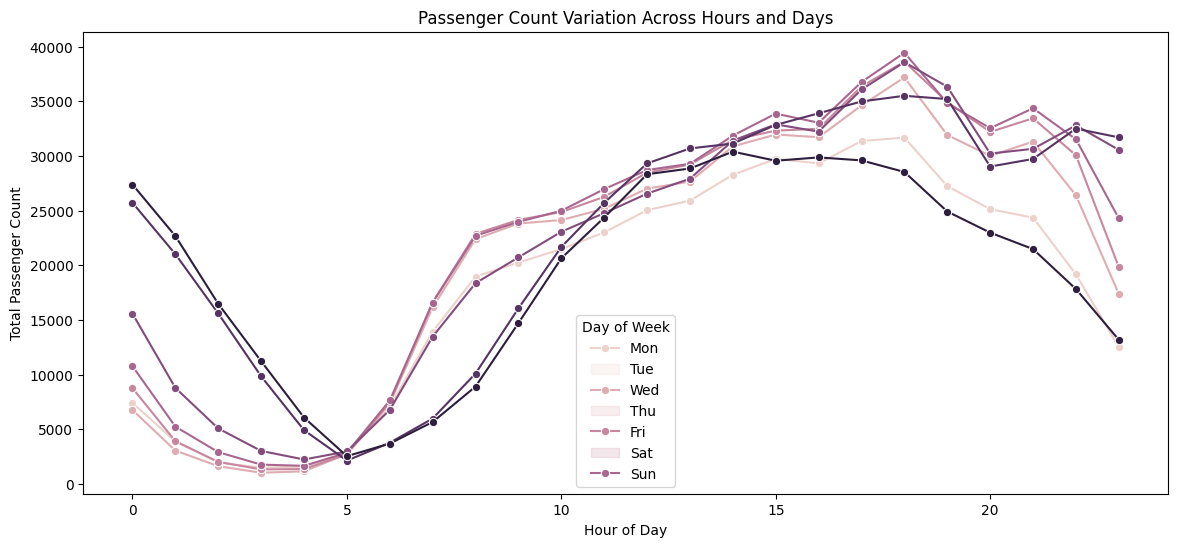

In [66]:
# See how passenger count varies across hours and days
df["dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek  # Monday=0, Sunday=6
passenger_counts = df.groupby(["dayofweek", "hour"])["passenger_count"].sum().reset_index()
print(passenger_counts.head())

plt.figure(figsize=(14,6))
sns.lineplot(data=passenger_counts, x="hour", y="passenger_count", hue="dayofweek", marker="o")
plt.title("Passenger Count Variation Across Hours and Days")
plt.xlabel("Hour of Day")
plt.ylabel("Total Passenger Count")
plt.legend(title="Day of Week", labels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

     PULocationID  passenger_count
29             30         2.000000
5               6         1.900000
58             59         1.750000
187           195         1.725000
11             12         1.707381
199           207         1.657143
92             93         1.561205
252           261         1.513826
186           194         1.510204
165           172         1.500000
                               zone  passenger_count
0                     Broad Channel         2.000000
1           Arrochar/Fort Wadsworth         1.900000
2                      Crotona Park         1.750000
3                          Red Hook         1.725000
4                      Battery Park         1.707381
5  Saint Michaels Cemetery/Woodside         1.657143
6      Flushing Meadows-Corona Park         1.561205
7                World Trade Center         1.513826
8                   Randalls Island         1.510204
9            New Dorp/Midland Beach         1.500000


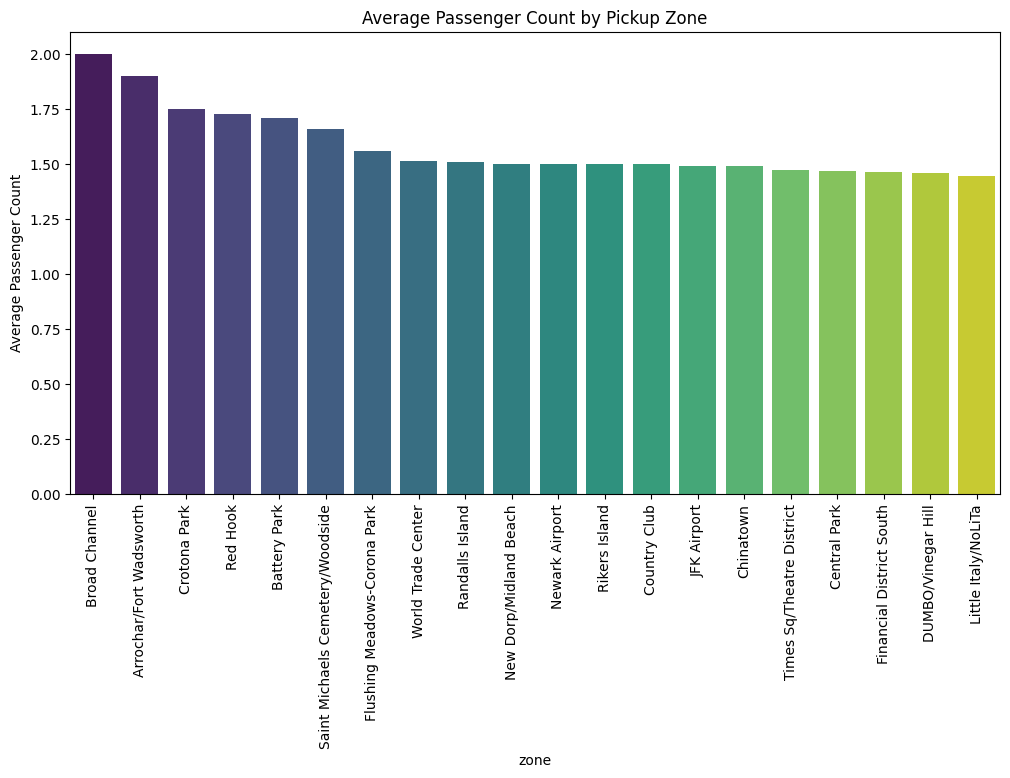

In [67]:
# How does passenger count vary across zones

# Average passenger count per pickup zone
passenger_by_zone = (
    df.groupby("PULocationID")["passenger_count"]
      .mean()
      .reset_index()
      .sort_values("passenger_count", ascending=False)
)

print(passenger_by_zone.head(10))  # Top 10 zones

#zones = pd.read_csv("taxi_zone_lookup.csv")
passenger_by_zone = passenger_by_zone.merge(zones, left_on="PULocationID", right_on="LocationID")

print(passenger_by_zone[["zone", "passenger_count"]].head(10))

plt.figure(figsize=(12,6))
sns.barplot(data=passenger_by_zone.head(20), x="zone", y="passenger_count", palette="viridis")
plt.xticks(rotation=90)
plt.title("Average Passenger Count by Pickup Zone")
plt.ylabel("Average Passenger Count")
plt.show()

In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [68]:
# How often is each surcharge applied?

df['congestion_surcharge'].unique()

surcharge_counts = df["congestion_surcharge"].value_counts().reset_index()
surcharge_counts.columns = ["congestion_surcharge", "count"]
print(surcharge_counts)

total_trips = len(df)
surcharge_counts["share"] = surcharge_counts["count"] / total_trips * 100
print(surcharge_counts)

   congestion_surcharge    count
0                  2.50  2422495
1                  0.00   179198
2                  2.75        1
3                  0.50        1
   congestion_surcharge    count      share
0                  2.50  2422495  93.112183
1                  0.00   179198   6.887740
2                  2.75        1   0.000038
3                  0.50        1   0.000038


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [69]:
#Location: Identifies zones with consistently high or low demand and adjusts cab allocation.
#Time of Day: Morning → residential zones, evening → business districts, late night → nightlife/airports.
#Day of Week: Weekdays emphasize commuter flows, weekends emphasize leisure/tourism.
#Demand Thresholds: Uses dynamic thresholds to increase or reduce supply based on trip counts.
#Recommendation table:
#Zone ID
#Hour of day
#Day of week
#Trip count
#Suggested operational recommendation
#Allocation strategy (increase, reduce, or maintain supply)

# Extract time features
#df["hour"] = df["pickup_datetime"].dt.hour
#df["dayofweek"] = df["pickup_datetime"].dt.dayofweek   # Monday=0, Sunday=6
df["month"] = df["pickup_datetime"].dt.month

# Step 1: Aggregate demand by zone, hour, day
demand = (
    df.groupby(["PULocationID", "hour", "dayofweek"])
      .size()
      .reset_index(name="trip_count")
)

# Step 2: Define thresholds for high/low demand zones
avg_demand = demand["trip_count"].mean()
high_demand_zones = demand[demand["trip_count"] > avg_demand]
low_demand_zones = demand[demand["trip_count"] <= avg_demand]

# Step 3: Strategic recommendations encoded as parameters
def recommend_allocation(row):
    if row["hour"] in range(6,10):   # Morning commute
        return "Increase supply in residential zones"
    elif row["hour"] in range(17,21): # Evening commute
        return "Focus on business districts and transit hubs"
    elif row["hour"] in range(23,4):  # Late night
        return "Concentrate on nightlife zones and airports"
    else:
        return "Maintain balanced distribution"

demand["recommendation"] = demand.apply(recommend_allocation, axis=1)

# Step 4: Example optimization strategy
# Adjust supply dynamically based on demand thresholds
def allocate_cabs(trip_count):
    if trip_count > avg_demand * 1.5:
        return "Allocate +30% more cabs"
    elif trip_count < avg_demand * 0.5:
        return "Reduce supply by 20%"
    else:
        return "Maintain current supply"

demand["allocation_strategy"] = demand["trip_count"].apply(allocate_cabs)

#merge demand with zones to get the zone name:
demand = demand.merge(zones, left_on="PULocationID", right_on="LocationID", how="inner")

# Step 5: Output actionable recommendations
demand[[ "zone", "hour", "dayofweek","trip_count_x","recommendation", "allocation_strategy"]].head(15)

,zone,hour,dayofweek,trip_count_x,recommendation,allocation_strategy
0,Newark Airport,3,4,1,Maintain balanced distribution,Reduce supply by 20%
1,Newark Airport,3,5,1,Maintain balanced distribution,Reduce supply by 20%
2,Newark Airport,3,6,1,Maintain balanced distribution,Reduce supply by 20%
3,Newark Airport,4,0,1,Maintain balanced distribution,Reduce supply by 20%
4,Newark Airport,4,3,1,Maintain balanced distribution,Reduce supply by 20%
5,Newark Airport,5,4,1,Maintain balanced distribution,Reduce supply by 20%
6,Newark Airport,5,6,1,Maintain balanced distribution,Reduce supply by 20%
7,Newark Airport,6,1,3,Increase supply in residential zones,Reduce supply by 20%
8,Newark Airport,6,4,1,Increase supply in residential zones,Reduce supply by 20%
9,Newark Airport,6,5,1,Increase supply in residential zones,Reduce supply by 20%


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [70]:
#Time of Day: Morning → residential zones, evening → business districts, late night → nightlife/airports.
#Day of Week: Weekdays emphasize commuter flows, weekends emphasize leisure/tourism.
#Month/Season: Holidays → airports/shopping, rainy months → residential zones.
#Output: A table showing zone, time, demand, and recommended positioning strategy.
#rule-based dispatch recommendation system.

# Aggregate demand by zone, hour, day, month
demand = (
    df.groupby(["PULocationID", "hour", "dayofweek", "month"])
      .size()
      .reset_index(name="trip_count")
)

# Define strategic positioning rules
def positioning_strategy(hour, dayofweek, month):
    # Time-of-day rules
    if 6 <= hour <= 9:   # Morning commute
        return "Increase supply in residential zones and airports"
    elif 17 <= hour <= 20:  # Evening commute
        return "Focus on business districts and transit hubs"
    elif (hour >= 23) or (hour <= 3):  # Late night
        return "Concentrate on nightlife zones and airports"
    elif 12 <= hour <= 15:  # Afternoon
        return "Spread evenly across commercial hubs and shopping districts"
    else:
        return "Maintain balanced distribution"

# Day-of-week rules
def day_strategy(dayofweek):
    if dayofweek < 5:  # Weekdays
        return "Prioritize commuter flows (residential ↔ business)"
    else:  # Weekends
        return "Increase coverage in entertainment and tourist zones"

# Month/season rules
def month_strategy(month):
    if month in [11, 12]:  # Holiday season
        return "Boost airport and shopping district coverage"
    elif month in [6, 7]:  # Rainy months (example)
        return "Increase coverage in residential areas (short trips surge)"
    else:
        return "Maintain standard allocation"

# Apply strategies
demand["time_strategy"] = demand.apply(lambda x: positioning_strategy(x["hour"], x["dayofweek"], x["month"]), axis=1)
demand["day_strategy"] = demand["dayofweek"].apply(day_strategy)
demand["month_strategy"] = demand["month"].apply(month_strategy)

demand = demand.merge(zones, left_on="PULocationID", right_on="LocationID", how="inner")

# Example output
demand[["zone", "hour", "dayofweek", "month",
              "trip_count_x", "time_strategy", "day_strategy", "month_strategy"]].head(20)


,zone,hour,dayofweek,month,trip_count_x,time_strategy,day_strategy,month_strategy
0,Newark Airport,3,4,1,1,Concentrate on nightlife zones and airports,Prioritize commuter flows (residential ↔ busin...,Maintain standard allocation
1,Newark Airport,3,5,4,1,Concentrate on nightlife zones and airports,Increase coverage in entertainment and tourist...,Maintain standard allocation
2,Newark Airport,3,6,5,1,Concentrate on nightlife zones and airports,Increase coverage in entertainment and tourist...,Maintain standard allocation
3,Newark Airport,4,0,10,1,Maintain balanced distribution,Prioritize commuter flows (residential ↔ busin...,Maintain standard allocation
4,Newark Airport,4,3,5,1,Maintain balanced distribution,Prioritize commuter flows (residential ↔ busin...,Maintain standard allocation
5,Newark Airport,5,4,9,1,Maintain balanced distribution,Prioritize commuter flows (residential ↔ busin...,Maintain standard allocation
6,Newark Airport,5,6,6,1,Maintain balanced distribution,Increase coverage in entertainment and tourist...,Increase coverage in residential areas (short ...
7,Newark Airport,6,1,5,1,Increase supply in residential zones and airports,Prioritize commuter flows (residential ↔ busin...,Maintain standard allocation
8,Newark Airport,6,1,8,1,Increase supply in residential zones and airports,Prioritize commuter flows (residential ↔ busin...,Maintain standard allocation
9,Newark Airport,6,1,11,1,Increase supply in residential zones and airports,Prioritize commuter flows (residential ↔ busin...,Boost airport and shopping district coverage


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

          current_revenue   new_revenue
VendorID                               
1             12530983.19  1.424645e+07
2             38737610.68  4.421265e+07
6                27114.29  2.801988e+04


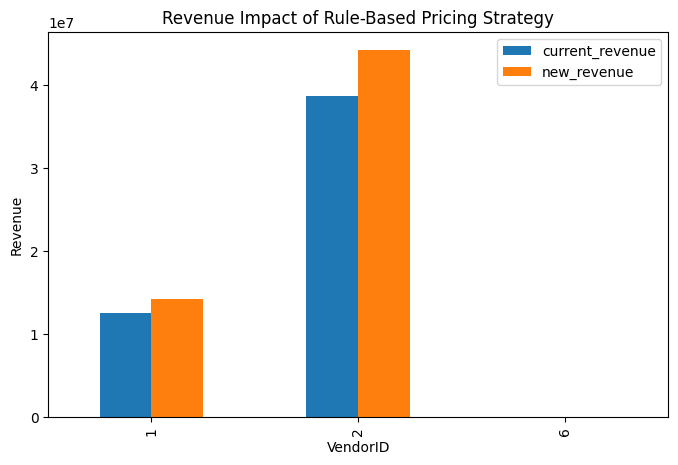

In [71]:
#Data driven adjustments to the pricing strategy: It applies rules based on distnace tiers, time of the day,day of the week and location to come up with pricing strategy
# Compute fare per mile
df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"].replace(0, np.nan)
df = df.dropna(subset=["fare_per_mile", "trip_distance", "total_amount"])


# -----------------------------
# Step 2: Define rule-based pricing adjustments
# -----------------------------
def pricing_strategy(row):
    base_fare = row["fare_per_mile"]

    # Distance tier rules
    if row["trip_distance"] <= 2:
        base_fare *= 1.10   # Short trips → premium pricing
    elif row["trip_distance"] <= 5:
        base_fare *= 1.00   # Medium trips → keep competitive
    else:
        base_fare *= 0.95   # Long trips → discount to attract riders

    # Time of day rules
    if 7 <= row["hour"] <= 9 or 17 <= row["hour"] <= 20:
        base_fare *= 1.15   # Peak commute hours → surcharge
    elif 23 <= row["hour"] or row["hour"] < 5:
        base_fare *= 1.05   # Night hours → mild surcharge

    # Day of week rules
    if row["day_of_week"] in ["Friday","Saturday"]:
        base_fare *= 1.10   # Weekend demand → higher pricing
    elif row["day_of_week"] == "Monday":
        base_fare *= 0.95   # Monday slump → slight discount

    # Location rules (example: airports vs residential)
    if row["PULocationID"] in [132,138,161]:  # JFK, LaGuardia, Newark IDs
        base_fare *= 1.20   # Airport pickups → premium
    elif row["PULocationID"] in [236,237]:   # Residential zones
        base_fare *= 0.90   # Residential → discount to stimulate demand

    return base_fare

# -----------------------------
# Step 3: Apply strategy
# -----------------------------
df["optimal_fare_per_mile"] = df.apply(pricing_strategy, axis=1)

# Estimate adjusted revenue
df["current_revenue"] = df["fare_per_mile"] * df["trip_distance"]
df["new_revenue"] = df["optimal_fare_per_mile"] * df["trip_distance"]

# -----------------------------
# Step 4: Compare results
# -----------------------------
summary = df.groupby("VendorID")[["current_revenue","new_revenue"]].sum()
print(summary)

# Optional: visualize impact
summary.plot(kind="bar", figsize=(8,5))
plt.title("Revenue Impact of Rule-Based Pricing Strategy")
plt.ylabel("Revenue")
plt.show()

